## Compute feature importances for the best ML-Pipeline

### Setup and Helper Fucntions

#### Imports

In [ ]:

from pathlib import Path

import pandas as pd
import numpy as np

import biopsykit as bp


from biopsykit.classification.model_selection import SklearnPipelinePermuter

from pepbench.io import load_best_performing_algos_b_point, load_preprocessed_training_data, compute_abs_error, \
     get_best_pipeline_results, get_best_estimator, get_pipeline_steps, compute_mae_std_from_permuter

import pingouin as pg

import matplotlib.pyplot as plt

#%matplotlib widget
%load_ext autoreload
%autoreload 2

#### Datapaths

In [2]:
model_path = Path(f"../../models")
data_path = Path(f"../../results")
result_path = Path(f"../../results")
rater = "rater_01"

### Load pipeline permuter with best ML-Pipeline

In [3]:
permuter_include_nan = SklearnPipelinePermuter.from_pickle(model_path.joinpath(f'b-point/rr-interval/{rater}/b_point_regression_hpc_0_baseline_result_rr_include_nan_rater_01.pkl'))

/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from

#### Select best ML-Pipeline

In [4]:
algo_dict_include_nan = {
    "MinMax_None_RFR_RR-Interval-Include-Nan": ('MinMaxScaler', 'RandomForestRegressor'),
}

In [5]:
algo_include_nan = algo_dict_include_nan["MinMax_None_RFR_RR-Interval-Include-Nan"]

In [6]:
permuter_include_nan_summary = permuter_include_nan.metric_summary()
permuter_include_nan_summary[permuter_include_nan_summary.index == algo_include_nan]

,,conf_matrix,conf_matrix_folds,true_labels,true_labels_folds,predicted_labels,predicted_labels_folds,train_indices,train_indices_folds,test_indices,test_indices_folds,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,test_neg_mean_absolute_error_fold_0,test_neg_mean_absolute_error_fold_1,test_neg_mean_absolute_error_fold_2,test_neg_mean_absolute_error_fold_3,test_neg_mean_absolute_error_fold_4
pipeline_scaler,pipeline_clf,,,,,,,,,,,,,,,,,
MinMaxScaler,RandomForestRegressor,[0.0],[],"[516.0, 520.0, 492.0, 492.0, 498.0, 334.0, 516...","[[516.0, 520.0, 492.0, 492.0, 498.0, 334.0, 51...","[525.699485398262, 520.0283937211624, 493.0129...","[[525.699485398262, 520.0283937211624, 493.012...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13...","[321, 322, 323, 324, 325, 326, 327, 328, 329, ...","[[321, 322, 323, 324, 325, 326, 327, 328, 329,...",8.153145,1.138026,6.413824,8.511139,7.921295,7.96797,9.951496


#### Show summary of best estimator per fold

In [7]:
pipeline_include_nan = permuter_include_nan.best_estimator_summary().loc[algo_include_nan]['best_estimator'].pipeline
pipeline_include_nan

[Pipeline(memory=Memory(location=cachedir/joblib),
          steps=[('scaler', MinMaxScaler()),
                 ('clf',
                  RandomForestRegressor(ccp_alpha=0.001,
                                        criterion='friedman_mse',
                                        max_features=0.8, n_estimators=250,
                                        random_state=RandomState(MT19937) at 0x16071F140))]),
 Pipeline(memory=Memory(location=cachedir/joblib),
          steps=[('scaler', MinMaxScaler()),
                 ('clf',
                  RandomForestRegressor(ccp_alpha=0.001,
                                        criterion='friedman_mse',
                                        max_depth=np.int64(40), max_features=0.8,
                                        min_impurity_decrease=0.01,
                                        n_estimators=250,
                                        random_state=RandomState(MT19937) at 0x16071F340))]),
 Pipeline(memory=Memory(location=cachedi

#### Get feature importances per fold

In [8]:
features_include_nan = np.array(pd.read_csv(data_path.joinpath(f'rr-interval/{rater}/train_data_b_point_rr_interval_include_nan.csv'), index_col=[0,1,2,3,4,5]).columns)
all_feature_importances = []
for fold in range(0,5,1):
    #selected_features = features_include_nan[pipeline_include_nan[fold]['reduce_dim'].get_support()]
    feature_importances = pipeline_include_nan[fold]['clf'].feature_importances_
    all_feature_importances.append(list(zip(features_include_nan, feature_importances)))
all_feature_importances = [
    [(key, float(value)) for key, value in inner_list]
    for inner_list in all_feature_importances
]
for fold, importances in enumerate(all_feature_importances):
    all_feature_importances[fold] = sorted(all_feature_importances[fold], key=lambda x: x[0], reverse=True)
all_feature_importances

[[('stern1985', 0.005605473834162119),
  ('sherwood1990', 0.002550038621745968),
  ('rr_interval_ms_estimated', 0.017658697820983615),
  ('pale2021', 0.0013006970829259512),
  ('miljkovic2022', 0.0033290955257245652),
  ('lozano2007-quadratic-regression', 0.00803547490442394),
  ('lozano2007-linear-regression', 0.14936996764799845),
  ('forouzanfar2018', 0.007239213990632267),
  ('drost2022', 0.7501286501566603),
  ('debski1993-second-derivative', 0.04457554895294814),
  ('arbol2017-third-derivative', 0.002904527067219161),
  ('arbol2017-second-derivative', 0.005983867807072049),
  ('arbol2017-isoelectric-crossings', 0.001318746587503501)],
 [('stern1985', 0.005346452573357876),
  ('sherwood1990', 0.0024944152819322426),
  ('rr_interval_ms_estimated', 0.008122627581595756),
  ('pale2021', 0.0010292787360665732),
  ('miljkovic2022', 0.002637421214141769),
  ('lozano2007-quadratic-regression', 0.00793637535476849),
  ('lozano2007-linear-regression', 0.17372168115837128),
  ('forouzanfar2

### Create general feature importance summary

In [9]:
# all feature importances has to be sorted by the feature name
averaged_feature_importances = list(zip([key for key, value in all_feature_importances[0]], np.mean([[value for key, value in fold] for fold in all_feature_importances], axis=0), np.std([[value for key, value in fold] for fold in all_feature_importances], axis=0)))
averaged_feature_importances = sorted(averaged_feature_importances, key=lambda x: x[1], reverse=True)
averaged_feature_importances

[('drost2022',
  np.float64(0.7488399588391463),
  np.float64(0.01762885538131582)),
 ('lozano2007-linear-regression',
  np.float64(0.15857869393644744),
  np.float64(0.01452927382562722)),
 ('debski1993-second-derivative',
  np.float64(0.043817893088027055),
  np.float64(0.007111436591663506)),
 ('rr_interval_ms_estimated',
  np.float64(0.011542031623048576),
  np.float64(0.003467781308598395)),
 ('forouzanfar2018',
  np.float64(0.008348224249834595),
  np.float64(0.0011847299978324133)),
 ('lozano2007-quadratic-regression',
  np.float64(0.007232216195851737),
  np.float64(0.0009883572103810772)),
 ('arbol2017-second-derivative',
  np.float64(0.005968585654484638),
  np.float64(0.0013720662852054583)),
 ('stern1985',
  np.float64(0.005793030183327687),
  np.float64(0.0003311672667939885)),
 ('miljkovic2022',
  np.float64(0.002956452888565071),
  np.float64(0.0006128381740283457)),
 ('arbol2017-third-derivative',
  np.float64(0.0025222361517477005),
  np.float64(0.00023461517406696365)

In [10]:
averaged_feature_importances_table = pd.DataFrame(averaged_feature_importances, columns=['feature', 'importance', 'std of importance'])
averaged_feature_importances_table["std in percent"] = averaged_feature_importances_table["std of importance"] / averaged_feature_importances_table["importance"] * 100
averaged_feature_importances_table

,feature,importance,std of importance,std in percent
0,drost2022,0.748840,0.017629,2.354155
1,lozano2007-linear-regression,0.158579,0.014529,9.162185
2,debski1993-second-derivative,0.043818,0.007111,16.229527
3,rr_interval_ms_estimated,0.011542,0.003468,30.044809
4,forouzanfar2018,0.008348,0.001185,14.191401
5,lozano2007-quadratic-regression,0.007232,0.000988,13.666035
6,arbol2017-second-derivative,0.005969,0.001372,22.988131
7,stern1985,0.005793,0.000331,5.716650
8,miljkovic2022,0.002956,0.000613,20.728833
9,arbol2017-third-derivative,0.002522,0.000235,9.301872


## Sanity checks: collinearity, held-out permutation importance, SHAP, and top-k retraining

The MDI-based importance above is computed **in-sample** (on training-fold impurity reduction), which is known to (a) be biased upward for high-cardinality/continuous features and (b) split credit somewhat arbitrarily between correlated features. Since all 13 features here are different estimates of the same underlying B-point (12 algorithms + `rr_interval_ms_estimated`), strong collinearity is expected. The cells below quantify that collinearity directly, cross-check the ranking with two importance measures that are not biased by in-sample impurity reduction, and empirically test whether a 2-3 feature model matches the full 13-feature model's performance.

In [11]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap
import seaborn as sns

full_data = pd.read_csv(data_path.joinpath(f'rr-interval/{rater}/train_data_b_point_rr_interval_include_nan.csv'), index_col=[0,1,2,3,4,5])
X_full = full_data.values

metric_summary_row = permuter_include_nan.metric_summary().loc[algo_include_nan]
test_indices_folds = metric_summary_row['test_indices_folds']
train_indices_folds = metric_summary_row['train_indices_folds']
true_labels_folds = metric_summary_row['true_labels_folds']

# the outer-CV test folds partition the full dataset exactly once each, so the true target
# for every row can be reconstructed from the fold-wise true_labels stored by the permuter
y_full = np.empty(X_full.shape[0])
for fold in range(5):
    y_full[list(test_indices_folds[fold])] = np.asarray(true_labels_folds[fold])

### Quantify collinearity: correlation matrix and Variance Inflation Factor (VIF)

,feature,VIF
7,lozano2007-linear-regression,5589.208211
8,lozano2007-quadratic-regression,2465.359555
1,arbol2017-isoelectric-crossings,1340.495951
11,sherwood1990,1279.569240
5,drost2022,714.738192
6,forouzanfar2018,296.098698
4,debski1993-second-derivative,253.666615
2,arbol2017-second-derivative,229.508022
9,miljkovic2022,215.706665
12,stern1985,204.846365


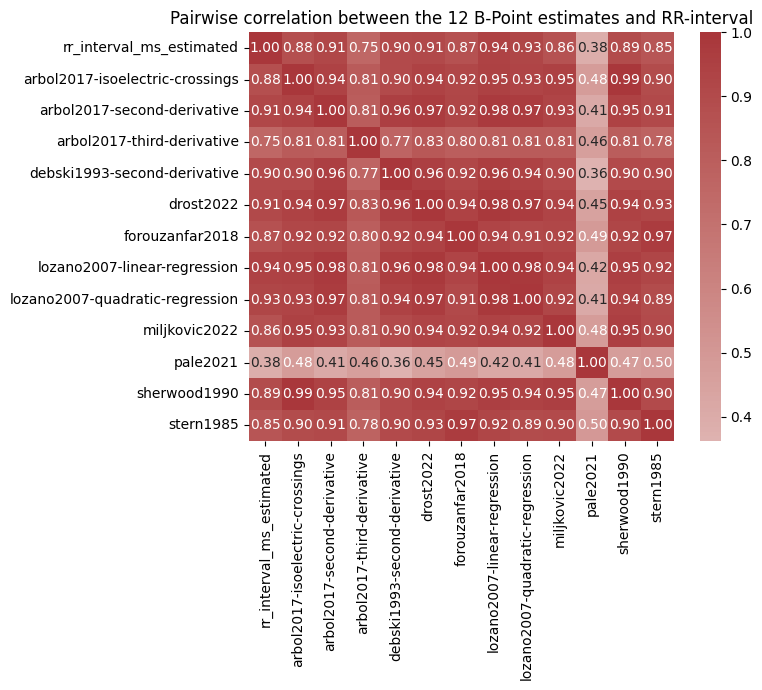

In [12]:
corr_matrix = full_data.corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_matrix, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Pairwise correlation between the 12 B-Point estimates and RR-interval")
fig.tight_layout()

# VIF needs complete cases (no NaNs); rows with any missing algorithm estimate are dropped for this check only
X_complete = full_data.dropna().values
vif_table = pd.DataFrame({
    "feature": features_include_nan,
    "VIF": [variance_inflation_factor(X_complete, i) for i in range(X_complete.shape[1])],
}).sort_values("VIF", ascending=False)
vif_table

**Result:** VIF for `lozano2007-linear-regression` is ~5589, `lozano2007-quadratic-regression` ~2465, and 9 of the 13 features exceed the common VIF > 10 rule-of-thumb for severe multicollinearity. This confirms the comment's premise directly rather than assuming it: the near-90% MDI share attributed to `drost2022` + `lozano2007-linear-regression` is measured under conditions where impurity-based importance is known to be unreliable.

### Permutation importance on held-out folds (bias-corrected cross-check)

Unlike MDI, permutation importance here is computed on each fold's **held-out test set**, so it is not affected by MDI's in-sample bias toward features the trees may have overfit to. Note it still does not fully resolve the collinearity issue on its own — permuting one of two highly correlated features lets the model fall back on its correlated twin, which can understate both. It is a genuinely different, complementary check, not a full fix.

In [13]:
perm_importances_per_fold = []
for fold in range(5):
    test_idx = list(test_indices_folds[fold])
    X_test = pd.DataFrame(X_full[test_idx], columns=features_include_nan)
    y_test = np.asarray(true_labels_folds[fold])
    result = permutation_importance(
        pipeline_include_nan[fold], X_test, y_test,
        scoring="neg_mean_absolute_error", n_repeats=20, random_state=0, n_jobs=-1,
    )
    perm_importances_per_fold.append(result.importances_mean)

perm_importances_per_fold = np.array(perm_importances_per_fold)
perm_importance_summary = pd.DataFrame({
    "feature": features_include_nan,
    "perm_importance_mean": perm_importances_per_fold.mean(axis=0),
    "perm_importance_std": perm_importances_per_fold.std(axis=0),
}).sort_values("perm_importance_mean", ascending=False)
perm_importance_summary["share_in_percent"] = (
    perm_importance_summary["perm_importance_mean"] / perm_importance_summary["perm_importance_mean"].sum() * 100
)
perm_importance_summary

/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/User

/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/User

/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/User

...

/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/User

/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/User

/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/User

/Users/abelluc/Code/pepbench/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


,feature,perm_importance_mean,perm_importance_std,share_in_percent
5,drost2022,39.899397,4.431301,50.797547
7,lozano2007-linear-regression,13.834308,3.002902,17.613021
0,rr_interval_ms_estimated,9.194856,2.470705,11.706346
4,debski1993-second-derivative,3.580291,0.807752,4.558214
6,forouzanfar2018,3.136264,0.421642,3.992905
12,stern1985,2.258587,0.576819,2.875499
8,lozano2007-quadratic-regression,2.167373,0.525087,2.759371
3,arbol2017-third-derivative,1.545625,0.536733,1.967798
2,arbol2017-second-derivative,1.055549,0.176651,1.343863
11,sherwood1990,0.808701,0.192134,1.029591


### SHAP importance (per-sample attribution, third independent view)

`tree_path_dependent` perturbation is used because the `RandomForestRegressor` was trained on data with missing values (native NaN support added in scikit-learn 1.4), and TreeSHAP's `interventional` mode with an explicit background sample is not compatible with that missing-value routing (its additivity check fails). Note SHAP is a useful additional, independent view, but — like MDI and permutation importance — it is not a full fix for collinearity either: TreeSHAP's path-dependent mode also splits credit among correlated features according to how the trees happened to split on them.

In [26]:
shap_abs_per_fold = []
shap_pct_per_sample = []
shap_values_per_fold = []
X_test_scaled_per_fold = []
for fold in range(5):
    test_idx = list(test_indices_folds[fold])
    scaler = pipeline_include_nan[fold]["scaler"]
    clf = pipeline_include_nan[fold]["clf"]
    X_test_scaled = scaler.transform(X_full[test_idx])
    explainer = shap.TreeExplainer(clf, feature_perturbation="tree_path_dependent")
    shap_values_fold = explainer.shap_values(X_test_scaled, check_additivity=False)
    abs_shap_fold = np.abs(shap_values_fold)
    shap_abs_per_fold.append(abs_shap_fold.mean(axis=0))
    # per-sample share: for each test sample, what % of *that sample's* total |SHAP| each feature accounts for
    shap_pct_per_sample.append(abs_shap_fold / abs_shap_fold.sum(axis=1, keepdims=True) * 100)
    shap_values_per_fold.append(shap_values_fold)
    X_test_scaled_per_fold.append(X_test_scaled)

shap_abs_per_fold = np.array(shap_abs_per_fold)
shap_pct_per_sample = np.concatenate(shap_pct_per_sample, axis=0)
shap_importance_summary = pd.DataFrame({
    "feature": features_include_nan,
    "mean_abs_shap": shap_abs_per_fold.mean(axis=0),
    "std_abs_shap": shap_abs_per_fold.std(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
shap_importance_summary["share_in_percent"] = (
    shap_importance_summary["mean_abs_shap"] / shap_importance_summary["mean_abs_shap"].sum() * 100
)
# per-sample abs-SHAP share (mean/std over individual test samples, not over the fold-averaged means above)
shap_importance_summary["mean_abs_shap_pct_per_sample"] = shap_importance_summary["feature"].map(
    dict(zip(features_include_nan, shap_pct_per_sample.mean(axis=0)))
)
shap_importance_summary["std_abs_shap_pct_per_sample"] = shap_importance_summary["feature"].map(
    dict(zip(features_include_nan, shap_pct_per_sample.std(axis=0)))
)
shap_importance_summary

,feature,mean_abs_shap,std_abs_shap,share_in_percent,mean_abs_shap_pct_per_sample,std_abs_shap_pct_per_sample
5,drost2022,53.890648,2.502129,57.479017,52.100796,15.654781
7,lozano2007-linear-regression,13.660476,2.082288,14.570074,13.258132,5.719574
0,rr_interval_ms_estimated,6.806806,1.436333,7.260045,9.957166,8.052450
4,debski1993-second-derivative,6.110375,0.675323,6.517241,7.462568,4.403542
6,forouzanfar2018,4.063520,0.603947,4.334094,5.133338,3.861321
12,stern1985,2.634756,0.290590,2.810195,3.601975,3.209151
8,lozano2007-quadratic-regression,1.573602,0.446558,1.678382,1.684994,1.488116
11,sherwood1990,1.312022,0.208692,1.399384,1.690457,1.224698
3,arbol2017-third-derivative,1.223124,0.249807,1.304567,1.791042,1.713839
9,miljkovic2022,0.976092,0.243659,1.041086,1.296236,1.383053


KeyboardInterrupt: 

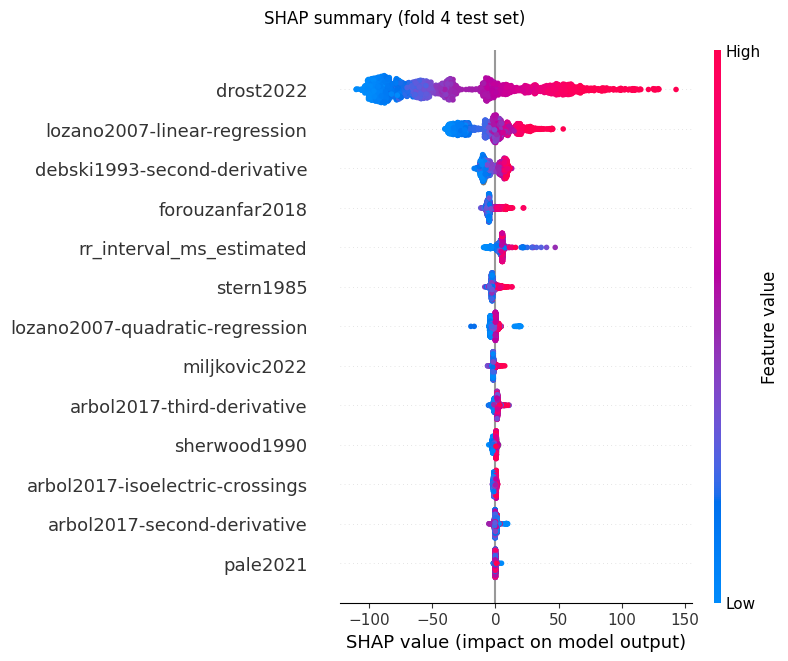

In [15]:
shap.summary_plot(
    shap_values_per_fold[-1],
    pd.DataFrame(X_test_scaled_per_fold[-1], columns=features_include_nan),
    show=False,
)
plt.gcf().suptitle("SHAP summary (fold 4 test set)")
plt.tight_layout()

### Does a top-2/top-3 feature model match the full 13-feature model?

Retrain a `RandomForestRegressor` (same per-fold hyperparameters as the best pipeline, same `MinMaxScaler` + outer-CV folds) restricted to the top-2 and top-3 features by permutation importance, and compare its MAE against the full 13-feature model's MAE on the same folds.

In [16]:
ranked_features = perm_importance_summary["feature"].tolist()
feature_to_col_idx = {feature: idx for idx, feature in enumerate(features_include_nan)}
best_params_per_fold = [
    {k: v for k, v in pipeline_include_nan[fold]["clf"].get_params().items() if k != "random_state"}
    for fold in range(5)
]


def mae_for_feature_subset(feature_subset):
    col_idx = [feature_to_col_idx[f] for f in feature_subset]
    fold_maes = []
    for fold in range(5):
        train_idx, test_idx = list(train_indices_folds[fold]), list(test_indices_folds[fold])
        X_train, X_test = X_full[np.ix_(train_idx, col_idx)], X_full[np.ix_(test_idx, col_idx)]
        y_train, y_test = y_full[train_idx], y_full[test_idx]
        model = Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", RandomForestRegressor(**best_params_per_fold[fold])),
        ])
        model.fit(X_train, y_train)
        fold_maes.append(mean_absolute_error(y_test, model.predict(X_test)))
    return fold_maes


topk_comparison_rows = []
for k in [2, 3, len(ranked_features)]:
    subset = ranked_features[:k]
    fold_maes = mae_for_feature_subset(subset)
    topk_comparison_rows.append({
        "n_features": k,
        "features": subset,
        "mae_mean": np.mean(fold_maes),
        "mae_std": np.std(fold_maes),
    })

topk_comparison_table = pd.DataFrame(topk_comparison_rows)
topk_comparison_table[["n_features", "mae_mean", "mae_std"]]

,n_features,mae_mean,mae_std
0,2,12.281565,0.804889
1,3,11.719558,0.706404
2,13,8.169136,1.168995


**Result:** top-2 features (`drost2022`, `lozano2007-linear-regression`) give MAE ≈ 12.3 ms, top-3 (adding `rr_interval_ms_estimated`) ≈ 11.7 ms, versus ≈ 8.1 ms for the full 13-feature model (matching the permuter's own reported 8.15 ms). The remaining features cut MAE by roughly a third — a real, non-trivial improvement despite their small MDI/SHAP/permutation shares. This directly contradicts a simplistic reading of "not really a 12-way fusion": the model **is** using the other estimates meaningfully, even though 2 features carry most of the *attributed* importance under collinearity. The right conclusion is that importance concentration under collinearity is not the same as those features being dispensable — both things the comment raised should be checked, and now are.